# Final Project

Ok, so today we'll be working with the `transactions`, `product`, and `hh_demographic` tables in the project_data folder.

* First, read in the transactions data.

* Read in the only columns `household_key`, `BASKET_ID`, `DAY`, `PRODUCT_ID`, `QUANTITY`, and `SALES_VALUE`.

* Convert `DAY`, `QUANTITY`, and `PRODUCT_ID` to the smallest appropriate integer types.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
transactions = pd.read_csv('project_data/project_transactions.csv')

display(transactions.info(memory_usage='deep'))
print('\n','-'*90,'\n')
transactions.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int64  
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(7)
memory usage: 180.1 MB


None


 ------------------------------------------------------------------------------------------ 



,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.0,0.0
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.0,0.0
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.0,0.0
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.0,0.0
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.0,0.0


---

## 1.1. Drop the Useless Columns

In [3]:
transactions = transactions.reindex(columns=list(transactions.columns[:6]))
transactions

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE
0,1364,26984896261,1,842930,1,2.19
1,1364,26984896261,1,897044,1,2.99
2,1364,26984896261,1,920955,1,3.09
3,1364,26984896261,1,937406,1,2.50
4,1364,26984896261,1,981760,1,0.60
...,...,...,...,...,...,...
2146306,1598,42305362535,711,92130,1,0.99
2146307,1598,42305362535,711,114102,1,8.89
2146308,1598,42305362535,711,133449,1,6.99
2146309,1598,42305362535,711,6923644,1,4.50


---

## 1.2. Change Columns Dtype

In [4]:
transactions = transactions.astype({'household_key':'int16',
                                    'DAY':'int16',
                                    'PRODUCT_ID':'int32',
                                    'QUANTITY':'int16'})
                                    
transactions.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   household_key  int16  
 1   BASKET_ID      int64  
 2   DAY            int16  
 3   PRODUCT_ID     int32  
 4   QUANTITY       int16  
 5   SALES_VALUE    float64
dtypes: float64(1), int16(3), int32(1), int64(1)
memory usage: 53.2 MB


In [5]:
# Use the following snippet to create a Date Column.
transactions = (
    transactions
    .assign(date = (pd.to_datetime("2016", format='%Y') 
                    + pd.to_timedelta(transactions["DAY"].sub(1).astype(str) + " days"))
           )
    .drop(["DAY"], axis=1)
)

In [6]:
transactions

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,date
0,1364,26984896261,842930,1,2.19,2016-01-01
1,1364,26984896261,897044,1,2.99,2016-01-01
2,1364,26984896261,920955,1,3.09,2016-01-01
3,1364,26984896261,937406,1,2.50,2016-01-01
4,1364,26984896261,981760,1,0.60,2016-01-01
...,...,...,...,...,...,...
2146306,1598,42305362535,92130,1,0.99,2017-12-11
2146307,1598,42305362535,114102,1,8.89,2017-12-11
2146308,1598,42305362535,133449,1,6.99,2017-12-11
2146309,1598,42305362535,6923644,1,4.50,2017-12-11


## TIME BASED ANALYSIS

* Plot the sum of sales by month. Are sales growing over time?
* Next, plot the same series after filtering down to dates April 2016 and October 2017.
* Then, plot the sum of monthly sales in 2016 vs the monthly sales 2017.
* Finally, plot total sales by day of week.

In [7]:
p01 = (transactions
    .set_index('date')
    .sort_index()
    .loc[:, 'SALES_VALUE']
    .resample('ME')
    .sum()
)

p01

date
2016-01-31     46557.97
2016-02-29     97315.16
2016-03-31    185521.82
2016-04-30    267801.38
2016-05-31    298319.14
2016-06-30    288952.45
2016-07-31    296488.02
2016-08-31    303951.35
2016-09-30    302040.56
2016-10-31    309962.42
2016-11-30    304764.41
2016-12-31    310456.27
2017-01-31    320301.20
2017-02-28    298058.26
2017-03-31    325511.23
2017-04-30    308786.99
2017-05-31    328829.68
2017-06-30    304792.96
2017-07-31    312853.52
2017-08-31    341670.16
2017-09-30    317498.59
2017-10-31    346065.23
2017-11-30    335458.18
2017-12-31    114286.55
Freq: ME, Name: SALES_VALUE, dtype: float64

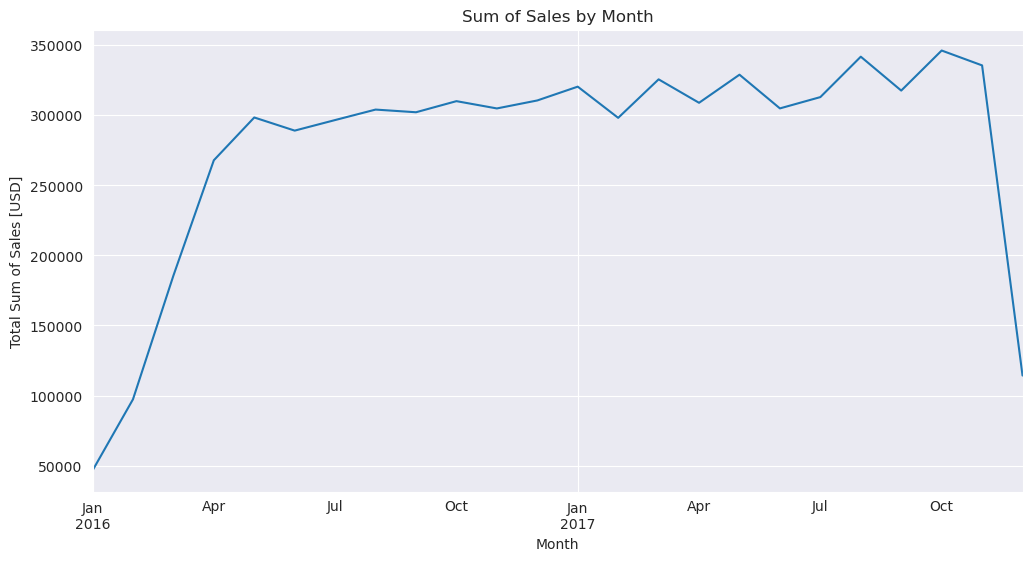

In [8]:
p01.plot(
    figsize=(12, 6),
    title='Sum of Sales by Month',
    xlabel='Month',
    ylabel='Total Sum of Sales [USD]'
    );

<Axes: title={'center': 'Sum of Sales by Month'}, xlabel='Month', ylabel='Total Sum of Sales [USD]'>

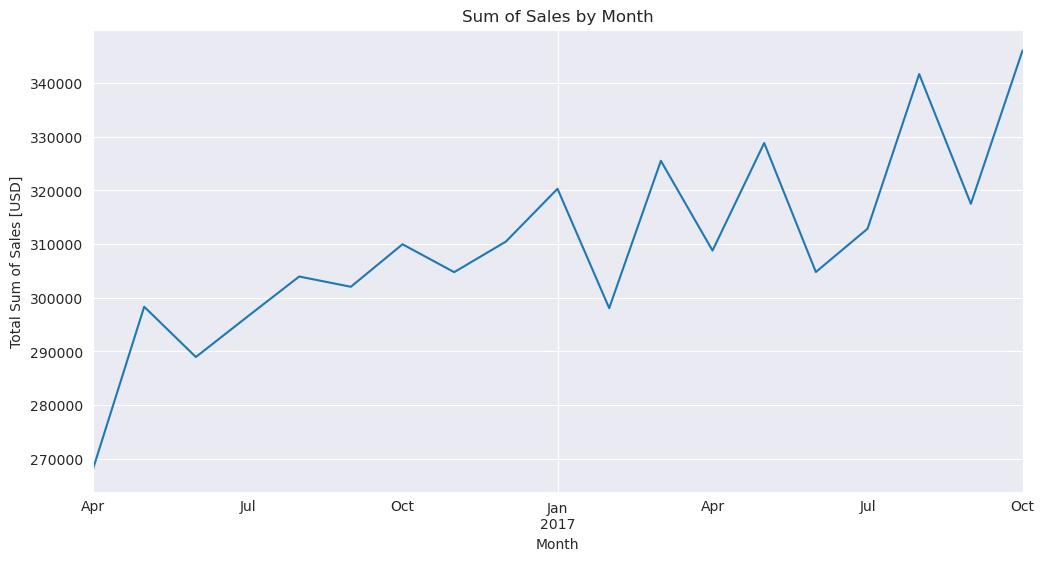

In [9]:
(transactions
    .set_index('date')
    .sort_index()
    .loc["2016-04":"2017-10", "SALES_VALUE"]
    .resample('ME').sum()
    .plot(
        figsize=(12, 6),
        title='Sum of Sales by Month',
        xlabel='Month',
        ylabel='Total Sum of Sales [USD]'
    ))

In [10]:
p02 = (transactions
 .set_index("date")
 .loc[:, ["SALES_VALUE"]]
 .resample("ME")
 .sum()
 .assign(year_prior = lambda x: x["SALES_VALUE"].shift(12))
 .loc["2017"]
)

p02

,SALES_VALUE,year_prior
date,,
2017-01-31,320301.20,46557.97
2017-02-28,298058.26,97315.16
2017-03-31,325511.23,185521.82
2017-04-30,308786.99,267801.38
2017-05-31,328829.68,298319.14
2017-06-30,304792.96,288952.45
2017-07-31,312853.52,296488.02
2017-08-31,341670.16,303951.35
2017-09-30,317498.59,302040.56


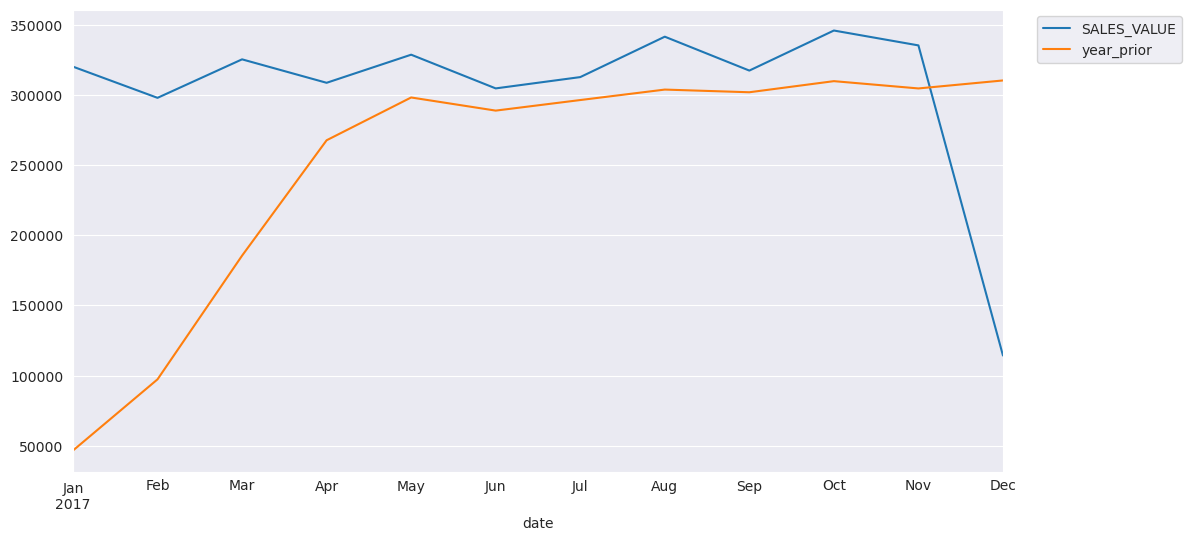

In [11]:
p02.plot(figsize=(12, 6)).legend(bbox_to_anchor=(1.2, 1));

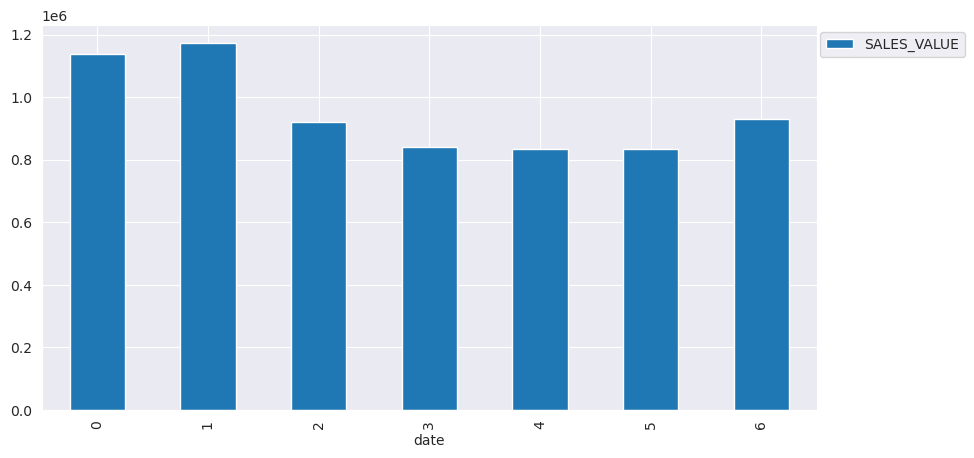

In [12]:
# Group transactions by dayofweek, then calculate sum and plot a bar chart
(transactions
 .groupby(transactions["date"].dt.dayofweek)
 .agg({"SALES_VALUE": "sum"})
 .plot.bar(figsize=(10,5))
    .legend(bbox_to_anchor=(1.2, 1))
)

<br><br>

---

# DEMOGRAPHICS

* Read in the `hh_demographic.csv` file, but only the columns `AGE_DESC`, `INCOME_DESC`, `household_key`, and `HH_COMP_DESC`. Convert the appropriate columns to the category dtype.


* Then group the transactions table by household_id, and calculate the sum of SALES VALUE by household.


* Once you've done that, join the demographics DataFrame to the aggregated transactions table. Since we're interested in analyzing the demographic data we have, make sure not to include rows from transactions that don't match.


* Plot the sum of sales by age_desc and income_desc (in separate charts).


* Then, create a pivot table of the mean household sales by `AGE_DESC` and `HH_COMP_DESC`. Which of our demographics have the highest average sales?


In [13]:
# Specify columns to include 
dem_cols = ["AGE_DESC", "INCOME_DESC", "household_key", "HH_COMP_DESC"]

# Convert the object columns here to category dtype
dem_dtypes = {"AGE_DESC": "category", "INCOME_DESC": "category", "HH_COMP_DESC":"category"}

demographics = pd.read_csv('project_data/hh_demographic.csv',
                          usecols=dem_cols,
                          dtype=dem_dtypes
                          )

demographics

,AGE_DESC,INCOME_DESC,HH_COMP_DESC,household_key
0,65+,35-49K,2 Adults No Kids,1
1,45-54,50-74K,2 Adults No Kids,7
2,25-34,25-34K,2 Adults Kids,8
3,25-34,75-99K,2 Adults Kids,13
4,45-54,50-74K,Single Female,16
...,...,...,...,...
796,35-44,50-74K,2 Adults No Kids,2494
797,45-54,75-99K,Unknown,2496
798,45-54,35-49K,Single Male,2497
799,25-34,50-74K,2 Adults No Kids,2498


In [14]:
# Create total sales by household dataframe
household_sales = (transactions
                   .groupby("household_key")
                   .agg({"SALES_VALUE": "sum"})
                  )

household_sales

,SALES_VALUE
household_key,
1,4330.16
2,1954.34
3,2653.21
4,1200.11
5,779.06
...,...
2095,3790.49
2096,1301.65
2097,8823.83


In [15]:
# Join household sales and demographics table on household_key (inner since we're interested in both sets)
household_sales_demo = (household_sales.merge(demographics, 
                             how="inner",
                             left_on='household_key',
                             right_on="household_key",
                             )
)

household_sales_demo

,household_key,SALES_VALUE,AGE_DESC,INCOME_DESC,HH_COMP_DESC
0,1,4330.16,65+,35-49K,2 Adults No Kids
1,7,3400.05,45-54,50-74K,2 Adults No Kids
2,8,5534.97,25-34,25-34K,2 Adults Kids
3,13,13190.92,25-34,75-99K,2 Adults Kids
4,16,1512.02,45-54,50-74K,Single Female
...,...,...,...,...,...
663,2087,7832.74,45-54,100-124K,Unknown
664,2088,4905.71,25-34,35-49K,Single Female
665,2092,2290.54,35-44,Under 15K,1 Adult Kids
666,2094,3055.52,45-54,50-74K,2 Adults No Kids


In [16]:
# Calculate sum of sales by age group
p03 = (household_sales_demo
            .groupby(["AGE_DESC"], observed=True)
            .agg({"SALES_VALUE": "sum"})
)

p03

,SALES_VALUE
AGE_DESC,
19-24,182991.03
25-34,635955.55
35-44,986670.19
45-54,1328371.19
55-64,258446.21
65+,260456.19


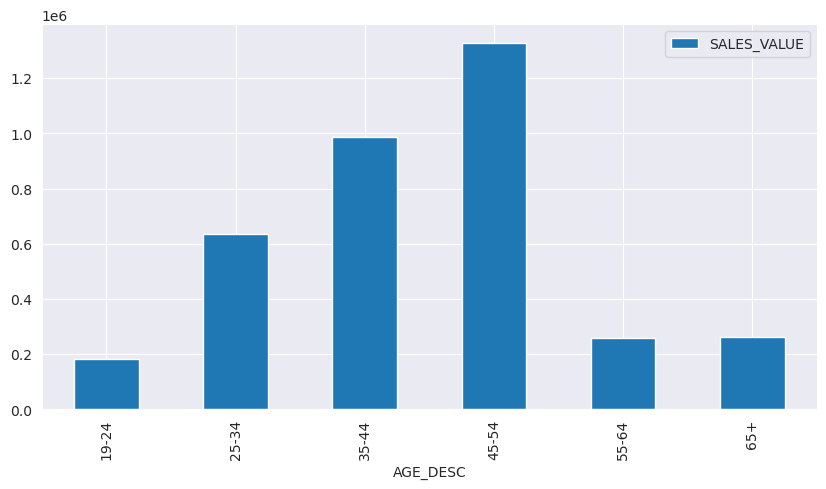

In [17]:
p03.plot.bar(
    figsize=(10, 5)
);

In [18]:
# Calculate sum of sales by income, ordered by magnitude
p04 = (household_sales_demo
         .groupby(["INCOME_DESC"], observed=True)
         .agg({"SALES_VALUE": "sum"})
         .sort_values("SALES_VALUE", ascending=False)
)

p04

,SALES_VALUE
INCOME_DESC,
50-74K,878344.14
35-49K,706011.17
75-99K,467274.35
25-34K,297183.42
Under 15K,282448.50
15-24K,274757.94
125-149K,243900.83
150-174K,199350.78
100-124K,176701.11


<Axes: xlabel='INCOME_DESC'>

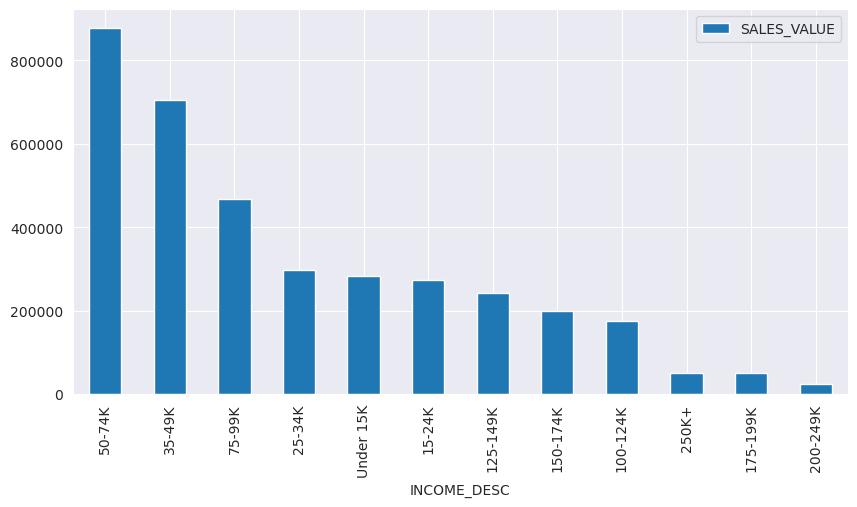

In [19]:
p04.plot.bar(figsize=(10, 5))

In [20]:
# Calculate mean household spend by Age Description and HH Composition
# Format with a heatmap across all cells
(household_sales_demo.pivot_table(index="AGE_DESC", 
                 columns="HH_COMP_DESC",
                 values="SALES_VALUE",
                 aggfunc="mean",
                 margins=True,
                 observed=True).astype('int')
 .style.background_gradient(cmap="RdYlGn", axis=None)
)

HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown,All
AGE_DESC,,,,,,,
19-24,7268,5428,4020,4576,3216,4911,4692
25-34,5512,5753,5638,4807,4909,7356,5435
35-44,6297,6691,6260,6015,4844,4227,6090
45-54,6632,6610,5839,4549,4636,4843,5534
55-64,3064,4695,5752,4816,3922,7973,5168
65+,4040,5536,4614,4059,3871,2879,4340
All,6032,6280,5599,4895,4544,4936,5468


In [21]:
# delete dfs we won't use anymore
del [household_sales_demo, household_sales]

<br><br>

---

# PRODUCT DEMOGRAPHICS

* Read in the product csv file.

* Only read in product_id and department from product (consider converting columns).

* Join the product DataFrame to transactions and demographics tables, performing an inner join when joining both tables.

* Finally, pivot the fully joined dataframe by AGE_DESC and DEPARTMENT, calculating the sum of sales. Which category does our youngest demographic perform well in?



In [22]:
# specify columns to use
product_cols = ["PRODUCT_ID", "DEPARTMENT"]

# specify datatypes for each column
product_dtypes = {"PRODUCT_ID": "Int32", "DEPARTMENT": "category"}

product = pd.read_csv('project_data/product.csv',
                     usecols=product_cols,
                     dtype=product_dtypes
)

product

,PRODUCT_ID,DEPARTMENT
0,25671,GROCERY
1,26081,MISC. TRANS.
2,26093,PASTRY
3,26190,GROCERY
4,26355,GROCERY
...,...,...
92348,18293142,DRUG GM
92349,18293439,DRUG GM
92350,18293696,DRUG GM
92351,18294080,DRUG GM


In [23]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   PRODUCT_ID  92353 non-null  Int32   
 1   DEPARTMENT  92353 non-null  category
dtypes: Int32(1), category(1)
memory usage: 542.7 KB


In [24]:
# Join all three tables together with an inner join
# Join product on product_id (only shared column)
trans_demo_dept = (transactions
                  .merge(demographics, 
                         how="inner",
                         left_on='household_key',
                         right_on="household_key",)
                  .merge(product,
                         how="inner",
                         left_on="PRODUCT_ID",
                         right_on="PRODUCT_ID")
)

trans_demo_dept

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,date,AGE_DESC,INCOME_DESC,HH_COMP_DESC,DEPARTMENT
0,1364,26984896261,842930,1,2.19,2016-01-01,65+,100-124K,Single Female,GROCERY
1,1364,26984896261,897044,1,2.99,2016-01-01,65+,100-124K,Single Female,GROCERY
2,1364,26984896261,920955,1,3.09,2016-01-01,65+,100-124K,Single Female,MEAT
3,1364,26984896261,937406,1,2.50,2016-01-01,65+,100-124K,Single Female,MEAT-PCKGD
4,1364,26984896261,981760,1,0.60,2016-01-01,65+,100-124K,Single Female,GROCERY
...,...,...,...,...,...,...,...,...,...,...
1161570,1369,42302712189,844054,1,1.29,2017-12-11,25-34,Under 15K,Single Male,GROCERY
1161571,1369,42302712189,844759,1,1.69,2017-12-11,25-34,Under 15K,Single Male,GROCERY
1161572,1369,42302712189,959737,2,25.98,2017-12-11,25-34,Under 15K,Single Male,GROCERY
1161573,1369,42302712189,1135096,1,1.99,2017-12-11,25-34,Under 15K,Single Male,GROCERY


In [25]:
trans_demo_dept.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161575 entries, 0 to 1161574
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   household_key  1161575 non-null  int16         
 1   BASKET_ID      1161575 non-null  int64         
 2   PRODUCT_ID     1161575 non-null  int32         
 3   QUANTITY       1161575 non-null  int16         
 4   SALES_VALUE    1161575 non-null  float64       
 5   date           1161575 non-null  datetime64[ns]
 6   AGE_DESC       1161575 non-null  category      
 7   INCOME_DESC    1161575 non-null  category      
 8   HH_COMP_DESC   1161575 non-null  category      
 9   DEPARTMENT     1161575 non-null  category      
dtypes: category(4), datetime64[ns](1), float64(1), int16(2), int32(1), int64(1)
memory usage: 39.9 MB


In [26]:
# Where does our youngest demographic rank near the top in sales?
(trans_demo_dept.pivot_table(index="DEPARTMENT",
                            columns="AGE_DESC",
                            values="SALES_VALUE",
                            aggfunc="sum",
                            observed=True)
                 .fillna(0)
                 .astype('int')
                 .style.background_gradient(cmap="RdYlGn", axis=1))

AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+
DEPARTMENT,,,,,,
,0,0,0,0,0,0
AUTOMOTIVE,11,21,72,55,0,16
CHEF SHOPPE,81,134,348,418,80,149
CNTRL/STORE SUP,2,0,1,9,2,0
COSMETICS,698,2273,4362,5187,986,600
COUP/STR & MFG,7,48,121,154,40,20
DAIRY DELI,3,3,7,16,3,1
DELI,4043,18181,34577,44334,9850,10462
DELI/SNACK BAR,0,0,6,1,0,3


<br><br>

---

# EXPORT

Finally, export your pivot table to an excel file. Make sure to provide a sheet name.

In [27]:
# Call to_excel on pivot table above - note the formatting gets passed to excel too!
(trans_demo_dept.pivot_table(index="DEPARTMENT",
                            columns="AGE_DESC",
                            values="SALES_VALUE",
                            aggfunc="sum",
                            observed=True)
 .style.background_gradient(cmap="RdYlGn", axis=1)
 .to_excel("demographic_category_sales.xlsx", sheet_name="sales_pivot")
)